# CSE620 Project 1
## Fall 2026

## Liam, Jack, David

## Defining functions and choosing starting points

It would be nice to pass simpler types and then convert to np.array within the functions.

In [13]:
from enum import Enum
from sympy import Symbol, cos
import numpy as np

class CustomFunction(Enum):
    QUADRATIC = "quadratic"
    BANANA_VALLEY = "banana_valley"
    COSINE_BUMPS = "cosine_bumps"

    @property
    def name(self):
        return self.value

    @property
    def symbolic_expression(self):
        x1, x2 = Symbol('x1'), Symbol('x2')
        match self:
            case CustomFunction.QUADRATIC:
                return x1**2 + x2**2
            case CustomFunction.BANANA_VALLEY:
                return (1 - x1)**2 + 100*(x2 - x1**2)**2
            case CustomFunction.COSINE_BUMPS:
                return x1**2 + x2**2 + 10*cos(x1) + 10*cos(x2)
            case _:
                raise ValueError(f"Unsupported function: {self}")

    @property
    def starting_points(self):
        match self:
            case CustomFunction.QUADRATIC:
                return [np.array([1, 2]), np.array([-3, 4]), np.array([-5, -6]), np.array([7, -8])]
            case CustomFunction.BANANA_VALLEY:
                return [np.array([1, 2]), np.array([-3, 4]), np.array([-5, -6]), np.array([7, -8])]
            case CustomFunction.COSINE_BUMPS:
                return [np.array([1, 2]), np.array([-3, 4]), np.array([-5, -6]), np.array([7, -8])]
            case _:
                raise ValueError(f"Unsupported function: {self}")
    @property
    def symbols(self):
        x1, x2 = Symbol('x1'), Symbol('x2')
        return (x1, x2)

## ADAM results demonstration.
Need to clean this up and do it for the rest of the methods.

In [14]:
from sympy import Symbol, cos
from methods import newtons_method, gradient_descent, adagrad, adam

results =[]
adam_results = []
gradient_descent_results = []
adagrad_results = []
newtons_method_results = []

adam_result_labels = []
gradient_descent_result_labels = []
adagrad_result_labels = []
newtons_method_result_labels = []

step_size = 0.1
for starting_point in CustomFunction.COSINE_BUMPS.starting_points:
    adam_results.append(adam(CustomFunction.COSINE_BUMPS.symbols, 
                    CustomFunction.COSINE_BUMPS.symbolic_expression, 
                    starting_point,
                    ((-9999, 9999), (-9999, 9999)),
                    step_size,
                    0.9,
                    0.999
                    ))
    adam_result_labels.append(f"adam: start={starting_point}, step={step_size}")
    

    gradient_descent_results.append(gradient_descent(CustomFunction.COSINE_BUMPS.symbols, 
                                    CustomFunction.COSINE_BUMPS.symbolic_expression, 
                                    starting_point,
                                    ((-9999, 9999), (-9999, 9999)),
                                    step_size))
    gradient_descent_result_labels.append(f"gradient_descent: start={starting_point}, step={step_size}")

    adagrad_results.append(adagrad(CustomFunction.COSINE_BUMPS.symbols, 
                           CustomFunction.COSINE_BUMPS.symbolic_expression, 
                           starting_point,
                           ((-9999, 9999), (-9999, 9999)),
                           step_size))
    adagrad_result_labels.append(f"adagrad: start={starting_point}, step={step_size}")

    newtons_method_results.append(newtons_method(CustomFunction.COSINE_BUMPS.symbols, 
                                  CustomFunction.COSINE_BUMPS.symbolic_expression, 
                                  starting_point,
                                  ((-10, 10), (-10, 10))))
    newtons_method_result_labels.append(f"newtons_method: start={starting_point}")

    results = adam_results + gradient_descent_results + adagrad_results + newtons_method_results
    result_labels = adam_result_labels + gradient_descent_result_labels + adagrad_result_labels + newtons_method_result_labels

Newton's method cannot handle this function. It is the only one with tight bounds.

<module 'matplotlib.pyplot' from 'c:\\Users\\jackm\\anaconda3\\envs\\cse620\\Lib\\site-packages\\matplotlib\\pyplot.py'>

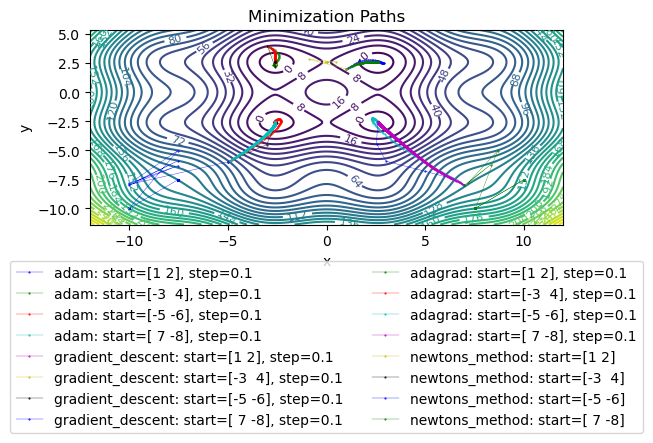

In [15]:
from utilities import plot_contours_with_path
plot_contours_with_path(CustomFunction.COSINE_BUMPS.symbols, 
                        CustomFunction.COSINE_BUMPS.symbolic_expression, 
                        results, 
                        result_labels,
                        title="Minimization Paths",
                    
)

We need a way to better control this plot, such as adding a legend. I think using keyword arguments could work.

We should also reduce the size or change the shape of the path points, and not use "cool" colors like light blue or cyan, as they are blending in with the topo lines too much.

In [16]:
from utilities import test_optimizer
import pandas as pd

step_sizes = list(np.array(range(1, 101))/100)
starting_point = CustomFunction.COSINE_BUMPS.starting_points[0]
step_size, starting_points, final_value, number_of_iterations = test_optimizer(
    optimizer_name="adam",
    step_size=step_sizes,
    starting_point=starting_point,
    beta1=0.9,
    beta2=0.999,
    x_symbols=CustomFunction.COSINE_BUMPS.symbols,
    f_symbolic=CustomFunction.COSINE_BUMPS.symbolic_expression,
    bounds=((-9999, 9999), (-9999, 9999))
)

df = pd.DataFrame({
    "Step Size": step_size,
    "Starting Point": starting_points,
    "Final Value": final_value,
    "Number of Iterations": number_of_iterations
})

df

,Step Size,Starting Point,Final Value,Number of Iterations
0,0.01,"[1, 2]",-3.617967,397
1,0.02,"[1, 2]",-3.617967,238
2,0.03,"[1, 2]",-3.617967,224
3,0.04,"[1, 2]",-3.617967,228
4,0.05,"[1, 2]",-3.617967,216
...,...,...,...,...
95,0.96,"[1, 2]",-3.617967,247
96,0.97,"[1, 2]",-3.617967,239
97,0.98,"[1, 2]",-3.617967,257
98,0.99,"[1, 2]",-3.617967,240


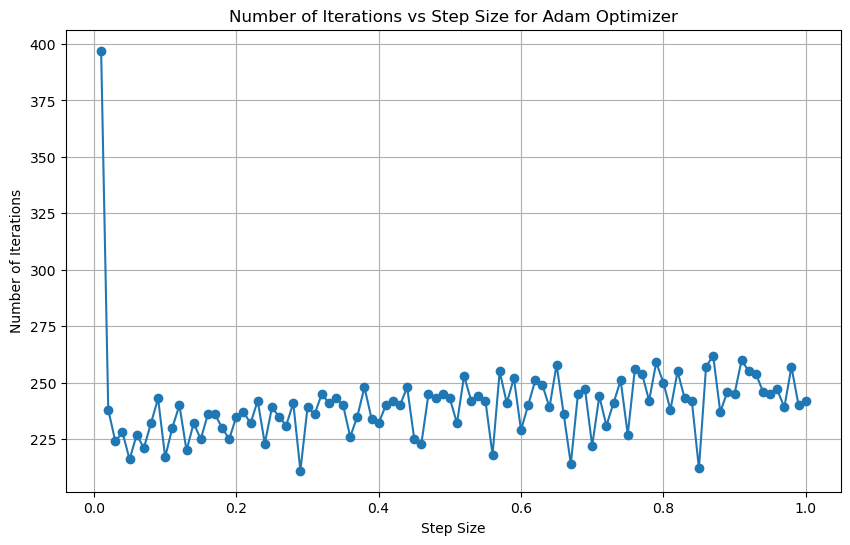

In [17]:
#plot the dataframe
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(step_size, number_of_iterations, marker='o', linestyle='-')
plt.xlabel('Step Size')
plt.ylabel('Number of Iterations')
plt.title('Number of Iterations vs Step Size for Adam Optimizer')
plt.grid(True)
plt.show()

In [ ]:
def optimizer_test_summary(optimizer_name,
                           _function: CustomFunction, 
                           step_sizes: list[float] | None = None,
                           **kwargs):
    
    print(f"Testing optimizer: {optimizer_name} on {_function.name} ({_function.symbolic_expression})")

    if step_sizes is None:
        step_sizes = [0.001, 0.01, 0.1]

    df_step_sizes = []
    df_starting_points = []
    df_final_values = []
    df_number_of_iterations = []
    for starting_point in _function.starting_points:
        step_size, starting_points, final_value, number_of_iterations = test_optimizer(
            optimizer_name=optimizer_name,
            step_size=step_sizes,
            starting_point=starting_point,
            x_symbols=_function.symbols,
            f_symbolic=_function.symbolic_expression,
            bounds=((-9999, 9999), (-9999, 9999)),
            **kwargs
        )

        df_step_sizes.extend(step_size)
        df_starting_points.extend(starting_points)
        df_final_values.extend(final_value)
        df_number_of_iterations.extend(number_of_iterations)

    df = pd.DataFrame({
        "Step Size": df_step_sizes,
        "Starting Point": df_starting_points,
        "Final Value": df_final_values,
        "Number of Iterations": df_number_of_iterations
    })

    return df

In [19]:
optimizer_name = "adam"
_function = CustomFunction.QUADRATIC

df = optimizer_test_summary(optimizer_name,
                            _function, 
                            step_sizes=None,
                            beta1=0.9, 
                            beta2=0.999,
                            max_iter=10000)
df

Testing optimizer: adam on quadratic


,Step Size,Starting Point,Final Value,Number of Iterations
0,0.001,"[1, 2]",3.902238e-08,5169
1,0.010,"[1, 2]",1.682846e-09,780
2,0.100,"[1, 2]",6.803797e-11,239
3,0.001,"[-3, 4]",4.349788e-08,8264
4,0.010,"[-3, 4]",5.984903e-09,1555
5,0.100,"[-3, 4]",6.162961e-10,238
6,0.001,"[-5, -6]",2.392211e-05,10000
7,0.010,"[-5, -6]",1.002510e-08,2244
8,0.100,"[-5, -6]",8.795716e-10,258
9,0.001,"[7, -8]",1.316555e-01,10000


In [20]:
optimizer_test_summary("adagrad",
                       CustomFunction.COSINE_BUMPS,
                       step_sizes=[0.1, 0.5, 1],
                       max_iter=10000)

Testing optimizer: adagrad on cosine_bumps


,Step Size,Starting Point,Final Value,Number of Iterations
0,0.1,"[1, 2]",-3.617967,447
1,0.5,"[1, 2]",-3.617967,27
2,1.0,"[1, 2]",-3.617967,18
3,0.1,"[-3, 4]",-3.617967,595
4,0.5,"[-3, 4]",-3.617967,45
5,1.0,"[-3, 4]",-3.617967,21
6,0.1,"[-5, -6]",-3.617966,2087
7,0.5,"[-5, -6]",-3.617967,129
8,1.0,"[-5, -6]",-3.617967,38
9,0.1,"[7, -8]",-3.617966,2897


In [21]:
optimizer_test_summary(
    "adagrad",
    CustomFunction.BANANA_VALLEY,
    max_iter=10000
)

Testing optimizer: adagrad on banana_valley


,Step Size,Starting Point,Final Value,Number of Iterations
0,0.001,"[1, 2]",19.564763,10000
1,0.010,"[1, 2]",0.092274,10000
2,0.100,"[1, 2]",0.016184,10000
3,0.001,"[-3, 4]",1403.323378,10000
4,0.010,"[-3, 4]",10.309993,10000
5,0.100,"[-3, 4]",9.652892,10000
6,0.001,"[-5, -6]",83515.839648,10000
7,0.010,"[-5, -6]",24411.007486,10000
8,0.100,"[-5, -6]",3.859588,10000
9,0.001,"[7, -8]",292712.405731,10000


In [22]:
optimizer_test_summary(
    "adam",
    CustomFunction.BANANA_VALLEY,
    max_iter=10000,
    beta1=0.9,
    beta2=0.999
)

Testing optimizer: adam on banana_valley


,Step Size,Starting Point,Final Value,Number of Iterations
0,0.001,"[1, 2]",1.292916e-02,10000
1,0.010,"[1, 2]",4.879731e-09,6820
2,0.100,"[1, 2]",1.609610e-09,2209
3,0.001,"[-3, 4]",9.548950e+00,10000
4,0.010,"[-3, 4]",3.406788e-03,10000
5,0.100,"[-3, 4]",3.228730e-09,5611
6,0.001,"[-5, -6]",1.098039e+01,10000
7,0.010,"[-5, -6]",2.312057e+00,10000
8,0.100,"[-5, -6]",1.084888e-06,10000
9,0.001,"[7, -8]",6.261509e+02,10000


In [23]:
optimizer_test_summary(
    "adam",
    CustomFunction.BANANA_VALLEY,
    max_iter = 10000,
    beta1 = 0.9,
    beta2 = 0.999
)

Testing optimizer: adam on banana_valley


,Step Size,Starting Point,Final Value,Number of Iterations
0,0.001,"[1, 2]",1.292916e-02,10000
1,0.010,"[1, 2]",4.879731e-09,6820
2,0.100,"[1, 2]",1.609610e-09,2209
3,0.001,"[-3, 4]",9.548950e+00,10000
4,0.010,"[-3, 4]",3.406788e-03,10000
5,0.100,"[-3, 4]",3.228730e-09,5611
6,0.001,"[-5, -6]",1.098039e+01,10000
7,0.010,"[-5, -6]",2.312057e+00,10000
8,0.100,"[-5, -6]",1.084888e-06,10000
9,0.001,"[7, -8]",6.261509e+02,10000
